# HW1 - Team 013

In [30]:
from datetime import datetime
import os
print(f"Last edited and run on {datetime.now().date()} by {os.getlogin()}")

Last edited and run on 2025-04-10 by maxpo


## Imports

In [31]:
import numpy as np
import pandas as pd
from typing import List
from tqdm import tqdm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from mrmr import mrmr_classif
from sklearn.feature_selection import mutual_info_classif
from skrebate import ReliefF
from PyIFS import InfFS
# from sklearn_relief import ReliefF
import math

## Constants

In [32]:
DEBUG = True
ROWS_TO_DEBUG = 400
RANDOM_SEED = 42
LABEL_COL = 'label'
DATASET_PATH = "./dataset.csv"

## Parameters

In [33]:
TEST_PERCENT = 0.2
NUM_FEATURES = [2, 5, 10, 20, 50, 100, 200]

## Feature selection methods

### Mutual Information - MI

In [34]:
def mi(num_features: int, X: np.array, y: np.array) -> List[int]:
    """
    Function performs feature selection using XXXXXXXXXXXXXXX method.

    Args:
        num_features (int): number of features to select.
        X (np.array): dataset with all the features.
        y (np.array): Label.

    Returns:
        List[int]: list of size num_features with the selected indecies of Xs columns.
    """
    # compute mutual information between each feature and the label
    mi_scores = mutual_info_classif(X, y)
    # get indices of the best features
    best_features_indices = np.argsort(mi_scores)[-num_features:]
    # extract feature names
    selected_features = best_features_indices.tolist()
    return selected_features
    

### MRMR

In [35]:
def mrmr(num_features: int, X: np.array, y: np.array = None) -> List[int]:
    """
    Function performs feature selection using XXXXXXXXXXXXXXX method.

    Args:
        num_features (int): number of features to select.
        X (np.array): dataset with all the features.
        y (np.array, optional): Label. Defaults to None.

    Returns:
        List[int]: list of size num_features with the selected indecies of Xs columns.
    """
    selected_features = mrmr_classif(X=pd.DataFrame(X), y=pd.Series(y), K=num_features)
    return selected_features

### ReliefF

In [36]:
def relief_f(num_features: int, X: np.array, y: np.array = None) -> List[int]:
    """
    Function performs feature selection using XXXXXXXXXXXXXXX method.

    Args:
        num_features (int): number of features to select.
        X (np.array): dataset with all the features.
        y (np.array, optional): Label. Defaults to None.

    Returns:
        List[int]: list of size num_features with the selected indecies of Xs columns.
    """
    relieff = ReliefF()
    relieff.fit(X, y)
    # selected_features = X.columns[relieff.top_features_]
    selected_features = np.argsort(relieff.feature_importances_)[-num_features:].tolist()
    return selected_features




### INF-FS

In [37]:
def inf_fs(num_features: int, X: np.array, y: np.array = None) -> List[int]:
    """
    Function performs feature selection using INF-FS method.

    Args:
        num_features (int): number of features to select.
        X (np.array): dataset with all the features.
        y (np.array, optional): Label. Defaults to None.

    Returns:
        List[int]: list of size num_features with the selected indecies of Xs columns.
    """

    # Apply Infinite Feature Selection
    inf = InfFS()
    ranked_features, weights = inf.infFS(X, y, alpha=0.5, supervision=1, verbose=0)
    # Get the top 10 features
    best_indices = ranked_features[:num_features]
    selected_features = best_indices.tolist()

    return selected_features


### Correlation Based

In [38]:
def correlation_based(num_features: int, X: np.array, y: np.array) -> List[int]:
    """
    Function performs feature selection using XXXXXXXXXXXXXXX method.

    Args:
        num_features (int): number of features to select.
        X (np.array): dataset with all the features.
        y (np.array): Label.

    Returns:
        List[int]: list of size num_features with the selected indecies of Xs columns.
    """
    correlations = pd.DataFrame(X).corrwith(pd.Series(y)).abs()
    most_correlated = correlations.nlargest(num_features).index.tolist()
    return most_correlated

### Random Selection

In [39]:
def random_selction(num_features: int, X: np.array, y: np.array = None) -> List[int]:
    """
    Function performs feature selection using XXXXXXXXXXXXXXX method.

    Args:
        num_features (int): number of features to select.
        X (np.array): dataset with all the features.
        y (np.array, optional): Label. Defaults to None.

    Returns:
        List[int]: list of size num_features with the selected indecies of Xs columns.
    """
    return np.random.choice(np.arange(X.shape[0]), replace=False, size=num_features)

## Load Data

In [40]:
dataset_df = pd.read_csv(DATASET_PATH)
if DEBUG:
    dataset_df = dataset_df.sample(ROWS_TO_DEBUG)
y = dataset_df[LABEL_COL].to_numpy()
X = dataset_df.drop(columns=[LABEL_COL]).to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PERCENT, random_state=RANDOM_SEED)

## Experimental Loop

### Mappings

In [41]:
FEATURE_SELECTION_METHOD = {
    # "INF-FS": inf_fs,
    "MRMR": mrmr,
    "MI": mi,
    "ReliefF":relief_f,
    "Random": random_selction,
    "Corr": correlation_based
}
IS_LABEL_NEEDED = {
    "INF-FS": True,
    "MRMR": True,
    "MI": True,
    "ReliefF":True,
    "Random": False,
    "Corr": True
}

### Expreiment run

In [ ]:
results_dict = {}
for num_features in tqdm(NUM_FEATURES):
    for fs_method_name, fs_method in FEATURE_SELECTION_METHOD.items():
        #x_selected_features = [ i for i in range(num_features)]
        x_selected_features = fs_method(num_features, X_train, y=y_train if IS_LABEL_NEEDED[fs_method_name] else None)
        # print(x_selected_features)
        X_train_after_fs = X_train[:, x_selected_features]
        rf_model_no_fs = RandomForestClassifier()
        rf_model_no_fs.fit(X_train_after_fs, y_train)
        results_dict[(num_features, fs_method_name)] = accuracy_score(y_test, rf_model_no_fs.predict(X_test[:, x_selected_features]))

## Results Table - Part A

In [ ]:
results_df = pd.DataFrame(list(results_dict.items()), columns=['Feature-Method', 'Accuracy'])
results_df[['Number of Features', 'Method']] = pd.DataFrame(results_df['Feature-Method'].tolist(), index=results_df.index)
results_df.drop(columns=['Feature-Method'], inplace=True)
results_df = results_df.pivot(index='Number of Features', columns='Method', values='Accuracy')
results_df = results_df.sort_index()
results_df = results_df.sort_index(axis=1)
results_df

Method,ReliefF
Number of Features,
2,0.1125
5,0.2250
10,0.2000
20,0.3250
50,0.3000
100,0.5875
200,0.6375


## All Features (No FS)

In [ ]:
rf_model_no_fs = RandomForestClassifier()
rf_model_no_fs.fit(X_train, y_train)
accuracy_score(y_test, rf_model_no_fs.predict(X_test))

0.8

## Extra: Heatmap visualization

<AxesSubplot:xlabel='Method', ylabel='Number of Features'>

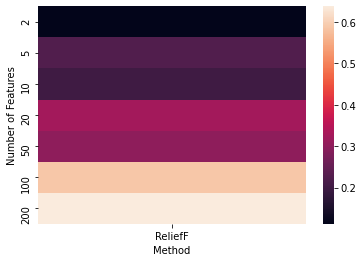

In [ ]:
sns.heatmap(results_df)